# **Regularização**

**Francisco A. Rodrigues**  
Universidade de São Paulo, São Carlos, Brasil  
<https://sites.icmc.usp.br/francisco>  

<hr>

Nessa aula vamos aprender a ajustar modelos e verificar quando ocorre overfitting. A ideia por trás do **overfitting** pode ser compreendida a partir da decomposição viés-variância. Para problemas de regressão com erro quadrático, o erro esperado de previsão em dados novos pode ser decomposto, de forma simplificada, em três componentes:

$$
\text{Erro} = \text{Viés}^2 + \text{Variância} + \sigma^2
$$

- **Viés (bias)** alto: ocorre quando o modelo é simples demais para representar adequadamente o padrão existente nos dados. Nesse caso, temos **underfitting**. Um exemplo seria ajustar uma reta a dados que apresentam uma relação claramente não linear.

- **Variância** alta: ocorre quando o modelo é excessivamente sensível aos dados utilizados no treinamento. Ele passa a capturar não apenas o padrão geral, mas também particularidades e ruídos daquela amostra. Nesse caso, temos **overfitting**. Como consequência, pequenas mudanças no conjunto de treinamento podem produzir modelos bastante diferentes.

- $\sigma^2$ representa o **erro irredutível**, associado ao ruído e à variabilidade inerente aos dados. Esse componente não pode ser eliminado simplesmente aumentando a complexidade do modelo ou ajustando seus hiperparâmetros.

Existe, portanto, um **compromisso entre viés e variância** (*bias-variance trade-off*). Aumentar a complexidade do modelo tende a reduzir o viés, pois permite representar relações mais complexas, mas também pode aumentar sua variância. O objetivo é encontrar um nível de complexidade que produza boa capacidade de generalização.

A **regularização** é uma forma elegante de deslizar esse controle: em vez de reduzir manualmente o número de atributos ou o grau do polinômio, penalizamos coeficientes grandes diretamente na função de custo, o que reduz a variância a um custo pequeno e controlado de viés.

Vamos tornar a ideia acima concreta. Vamos gerar dados a partir de uma função conhecida (uma senoide) e ajustar polinômios de diferentes graus $M$:

$$
f(x,\theta) = \theta_0 + \theta_1 x + \theta_2 x^2 + \ldots + \theta_M x^M
$$

Quanto maior $M$, mais flexível (complexo) é o modelo.

In [22]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

np.random.seed(10)

def function(x):
    # função geradora dos dados (desconhecida na prática)
    return np.sin(2 * np.pi * x)

# poucos pontos de treinamento -> favorece o overfitting em modelos complexos
N_train = 15
sigma = 0.2
x_train = np.linspace(0, 1, N_train)
y_train = function(x_train) + np.random.normal(0, sigma, N_train)
X_train = x_train.reshape(-1, 1)

xt = np.linspace(0, 1, 200)          # grade fina, só para plotar as curvas
Xt = xt.reshape(-1, 1)
yt = function(xt)                     # curva teórica (sem ruído)

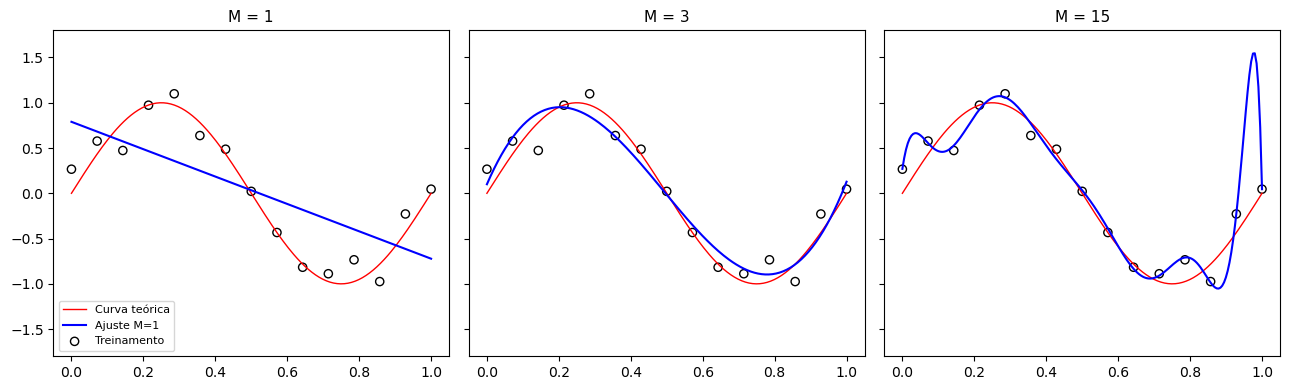

In [23]:
# Ajustamos M=1, M=3 e M=9 lado a lado, para comparar diretamente o efeito
# da complexidade do modelo sobre o ajuste.
graus = [1, 3, 15]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)

for grau, ax in zip(graus, axes):
    poly = PolynomialFeatures(degree=grau)
    modelo = LinearRegression().fit(poly.fit_transform(X_train), y_train)
    y_pred = modelo.predict(poly.fit_transform(Xt))

    ax.plot(xt, yt, "r-", label="Curva teórica", linewidth=1)
    ax.plot(xt, y_pred, "b-", label=f"Ajuste M={grau}")
    ax.scatter(x_train, y_train, facecolor="none", edgecolor="black", s=35, label="Treinamento")
    ax.set_title(f"M = {grau}", fontsize=11)
    ax.set_ylim(-1.8, 1.8)

axes[0].legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

Olhando os três painéis lado a lado:

- **M = 1** (reta): o modelo é rígido demais para capturar a curvatura da senoide, **underfitting** (viés alto).
- **M = 3**: captura bem a tendência geral — um bom compromisso.
- **M = 15**: a curva serpenteia para passar praticamente por cada ponto de treinamento, **overfitting** (variância alta). O modelo "decorou" o ruído, não a função.

Uma forma indireta de detectar esse comportamento é observar a **magnitude dos coeficientes** ajustados: os coeficientes costumam explodir em valor absoluto quando ocorre overfitting.

In [24]:
poly9 = PolynomialFeatures(degree=9)
modelo9 = LinearRegression().fit(poly9.fit_transform(X_train), y_train)
print("Coeficientes do modelo M=9:")
print(np.round(modelo9.coef_, 1))

Coeficientes do modelo M=9:
[    0.     10.2  -170.3  1341.7 -4722.2  7390.8 -3039.2 -5115.5  6462.6
 -2158.2]


Coeficientes na casa das centenas ou milhares (alternando de sinal) são um forte indício de overfitting. É exatamente esse excesso que a regularização vai penalizar.

#### O erro em função da complexidade

Em vez de olhar caso a caso, podemos medir sistematicamente o erro de treinamento e de teste para cada grau de polinômio.

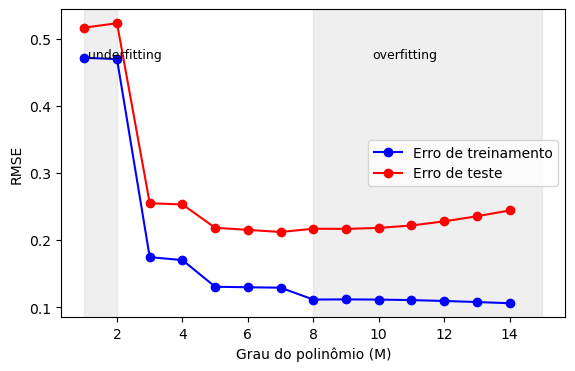

In [25]:
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

N_test = 30
x_test = np.linspace(0, 1, N_test)
y_test = function(x_test) + np.random.normal(0, sigma, N_test)
X_test = x_test.reshape(-1, 1)

erros_treino, erros_teste = [], []
m = 15
graus_avaliados = np.arange(1, m)

for M in graus_avaliados:
    poly = PolynomialFeatures(degree=M)
    Xtr_M = poly.fit_transform(X_train)
    Xte_M = poly.fit_transform(X_test)

    modelo = LinearRegression().fit(Xtr_M, y_train)
    erros_treino.append(rmse(modelo.predict(Xtr_M), y_train))
    erros_teste.append(rmse(modelo.predict(Xte_M), y_test))

fig = plt.figure(figsize=(6.5, 4))
plt.plot(graus_avaliados, erros_treino, "b-o", label="Erro de treinamento")
plt.plot(graus_avaliados, erros_teste, "r-o", label="Erro de teste")
plt.axvspan(1, 2, color="gray", alpha=0.12)
plt.axvspan(8, m, color="gray", alpha=0.12)
plt.text(1.1, max(erros_teste) * 0.9, "underfitting", fontsize=9)
plt.text(9.8, max(erros_teste) * 0.9, "overfitting", fontsize=9)
plt.xlabel("Grau do polinômio (M)")
plt.ylabel("RMSE")
plt.legend(fontsize=10)
plt.show()

O padrão clássico aparece: o erro de **treinamento** cai (quase) monotonicamente com a complexidade, afinal, um modelo mais flexível sempre consegue se ajustar melhor aos pontos que já viu. Já o erro de **teste** cai até um ponto e depois **volta a subir**: esse é o sinal  de overfitting. O melhor grau é aquele que minimiza o erro de teste, não o de treinamento.

**Um paliativo natural é aumentar os dados**: com mais pontos de treinamento, fica mais difícil para um modelo complexo se ajustar ao ruído (há menos "espaço" para memorizar), e o overfitting demora mais para aparecer. Mas nem sempre temos a opção de coletar mais dados, e é exatamente aí que a regularização se torna útil: ela nos permite manter um modelo flexível (M alto) **sem pagar o preço do overfitting**, mesmo com poucos dados.

### Regularização Ridge (L2)

A ideia da regularização é simples: em vez de limitar o grau do polinômio, deixamos o modelo complexo, mas **penalizamos coeficientes grandes** diretamente na função de custo.

Seja $\text{RSS}(\theta) = \sum_i (y_i - f(x_i,\theta))^2$ o erro quadrático de treinamento usual (o mesmo que a regressão linear minimiza). O **Ridge** adiciona uma penalidade proporcional à **soma dos quadrados** dos coeficientes:
$$
\theta^{*} = \arg\min_\theta \; \text{RSS}(\theta) + \alpha \sum_{j=1}^{M} \theta_j^2
$$

O hiperparâmetro $\alpha \geq 0$ controla a força da penalização: $\alpha=0$ recupera a regressão linear comum, e $\alpha \to \infty$ encolhe todos os coeficientes para (perto de) zero.

O Ridge tem uma **solução fechada** simples (pode ser obtida derivando o custo e igualando a zero):

$$
\theta^{*} = (X^T X + \alpha I)^{-1} X^T y
$$

onde $X$ já deve estar centrado (média zero) para que o intercepto não seja penalizado junto com os demais coeficientes. Vamos verificar que essa fórmula bate exatamente com o resultado do `scikit-learn`.

In [26]:
from sklearn.linear_model import Ridge

rng = np.random.default_rng(0)
n, p = 100, 5
X_demo = rng.normal(size=(n, p))
theta_verdadeiro = np.array([3.0, -2.0, 0.5, 0.0, 1.5])
y_demo = X_demo @ theta_verdadeiro + rng.normal(0, 1, n)

# centraliza X e y (equivalente a remover o intercepto do problema)
Xc = X_demo - X_demo.mean(axis=0)
yc = y_demo - y_demo.mean()

alpha_demo = 2.0
I = np.eye(p)

# --- solução fechada, implementada manualmente ---
theta_manual = np.linalg.inv(Xc.T @ Xc + alpha_demo * I) @ Xc.T @ yc

# --- solução do scikit-learn (fit_intercept=False pois já centralizamos) ---
theta_sklearn = Ridge(alpha=alpha_demo, fit_intercept=False).fit(Xc, yc).coef_

print("Manual   :", np.round(theta_manual, 4))
print("sklearn  :", np.round(theta_sklearn, 4))
print("Diferença máxima:", np.max(np.abs(theta_manual - theta_sklearn)))

Manual   : [ 2.8535 -1.8665  0.5422  0.0267  1.5005]
sklearn  : [ 2.8535 -1.8665  0.5422  0.0267  1.5005]
Diferença máxima: 8.881784197001252e-16


As duas soluções coincidem (a menos de erro numérico), confirmando que o Ridge nada mais é do que essa fórmula de álgebra linear. Note também que, quanto maior $\alpha$, mais a matriz $X^TX + \alpha I$ se afasta de $X^TX$ e mais a solução se aproxima de $\theta = 0$. É assim que a penalidade "encolhe" os coeficientes.

Notem que a penalidade depende diretamente da **magnitude** de $\theta_j$. Se um atributo é medido em uma escala muito maior que outro, seu coeficiente naturalmente será pequeno, e a regularização vai penalizá-lo de forma desproporcional em relação a um atributo em escala pequena. Vamos ver isso na prática, usando a base **Diabetes** do `scikit-learn` (442 pacientes, 10 atributos clínicos, com o objetivo de prever a progressão da doença um ano após a medição inicial).

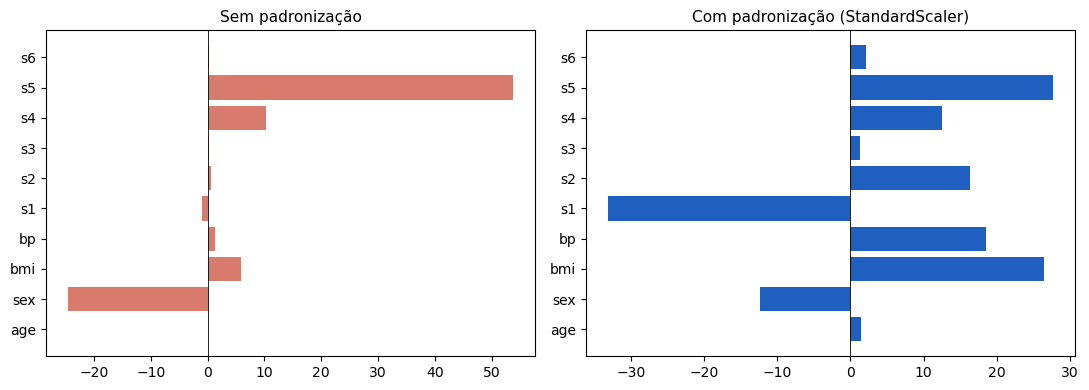

In [27]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

diabetes = load_diabetes(scaled=False)   # atributos em suas unidades originais (não pré-padronizados)
X, y = diabetes.data, diabetes.target
nomes = diabetes.feature_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

alpha_fixo = 1.0
ridge_sem_escala = Ridge(alpha=alpha_fixo).fit(X_train, y_train)

scaler = StandardScaler().fit(X_train)      # ajustado apenas no treino, para não vazar informação do teste
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
ridge_com_escala = Ridge(alpha=alpha_fixo).fit(X_train_s, y_train)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].barh(nomes, ridge_sem_escala.coef_, color="#d97b6c")
axes[0].set_title("Sem padronização", fontsize=11)
axes[1].barh(nomes, ridge_com_escala.coef_, color="#1f5fbf")
axes[1].set_title("Com padronização (StandardScaler)", fontsize=11)
for ax in axes:
    ax.axvline(0, color="black", linewidth=0.6)
plt.tight_layout()
plt.show()

Sem padronização, o atributo `sex` (uma variável binária, com desvio-padrão pequeno) recebe um coeficiente grande simplesmente por estar em uma escala pequena e não porque seja o atributo mais importante clinicamente. Depois de padronizar (média 0, desvio-padrão 1 em cada atributo), a comparação entre coeficientes passa a refletir de fato a importância relativa de cada variável. **Por isso, padronizar os atributos antes de aplicar Ridge, Lasso ou Elastic Net é uma etapa fundamental**.

Uma forma muito informativa de visualizar o efeito de $\alpha$ é acompanhar **todos os coeficientes simultaneamente** à medida que $\alpha$ cresce.

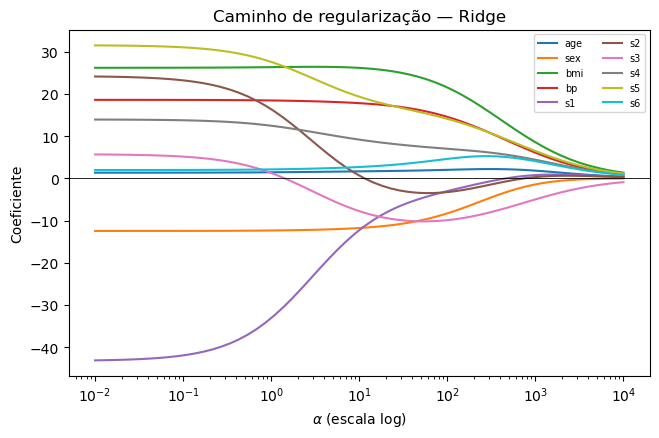

In [28]:
alphas_ridge = np.logspace(-2, 4, 60)
coefs_ridge = []

for a in alphas_ridge:
    modelo = Ridge(alpha=a).fit(X_train_s, y_train)
    coefs_ridge.append(modelo.coef_)

coefs_ridge = np.array(coefs_ridge)

fig = plt.figure(figsize=(7.5, 4.5))
for j, nome in enumerate(nomes):
    plt.plot(alphas_ridge, coefs_ridge[:, j], label=nome)
plt.xscale("log")
plt.axhline(0, color="black", linewidth=0.6)
plt.xlabel(r"$\alpha$ (escala log)")
plt.ylabel("Coeficiente")
plt.title("Caminho de regularização — Ridge")
plt.legend(fontsize=7, ncol=2)
plt.show()

Da esquerda para a direita, à medida que $\alpha$ cresce, **todos** os coeficientes encolhem suavemente em direção a zero, mas note que **nenhum deles chega a zero exatamente**, mesmo para $\alpha$ grande. Essa é a assinatura visual do Ridge.

### Regularização Lasso (L1)

O **Lasso** (*least absolute shrinkage and selection operator*) troca a penalidade quadrática por uma penalidade sobre o **valor absoluto** dos coeficientes:

$$
\theta^{*} = \arg\min_\theta \; \text{RSS}(\theta) + \alpha \sum_{j=1}^{M} |\theta_j|
$$

Diferente do Ridge, essa penalidade não tem uma solução fechada simples (a função $|\theta_j|$ não é diferenciável em $\theta_j=0$), então o `scikit-learn` a resolve numericamente.

Vamos observar o caminho de regularização do Lasso na mesma base de dados, para comparar diretamente com o Ridge.

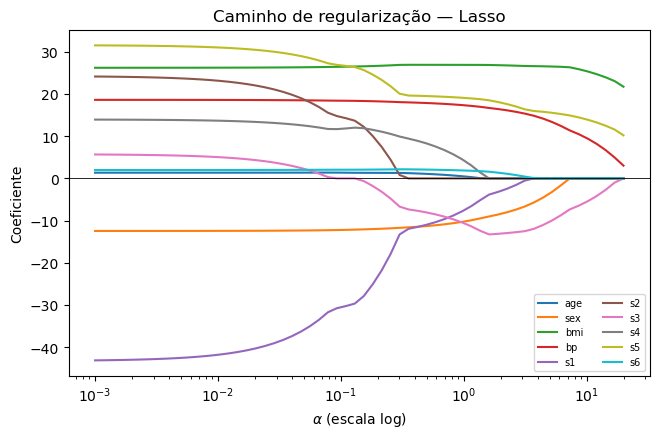

In [29]:
from sklearn.linear_model import Lasso

alphas_lasso = np.logspace(-3, 1.3, 60)
coefs_lasso = []

for a in alphas_lasso:
    modelo = Lasso(alpha=a, max_iter=10000).fit(X_train_s, y_train)
    coefs_lasso.append(modelo.coef_)

coefs_lasso = np.array(coefs_lasso)

fig = plt.figure(figsize=(7.5, 4.5))
for j, nome in enumerate(nomes):
    plt.plot(alphas_lasso, coefs_lasso[:, j], label=nome)
plt.xscale("log")
plt.axhline(0, color="black", linewidth=0.6)
plt.xlabel(r"$\alpha$ (escala log)")
plt.ylabel("Coeficiente")
plt.title("Caminho de regularização — Lasso")
plt.legend(fontsize=7, ncol=2)
plt.show()

Compare esse gráfico com o do Ridge: aqui, à medida que $\alpha$ cresce, os coeficientes **atingem exatamente zero**, um de cada vez, até restar apenas o atributo mais informativo (tipicamente `bmi`, o índice de massa corporal, e `s5`, um marcador de colesterol). Essa propriedade é extremamente útil quando queremos não apenas um bom modelo preditivo, mas também **interpretabilidade**: o Lasso nos diz diretamente quais atributos podem ser descartados sem grande perda de qualidade.

No entanto, a capacidade do Lasso de zerar coeficientes tem um custo: quando dois atributos são **fortemente correlacionados** (carregam quase a mesma informação), o Lasso tende a escolher **um deles arbitrariamente** e zerar o outro. Essa escolha pode mudar drasticamente com pequenas alterações na amostra de treinamento.

Vamos demonstrar isso diretamente: criamos dois atributos artificialmente quase idênticos ($x_2 \approx x_1$, correlação $>0.99$), ambos com peso verdadeiro igual a 2. Depois, reamostramos os dados repetidamente (bootstrap) e observamos como os coeficientes estimados por Ridge e por Lasso se comportam de uma reamostragem para outra.

In [30]:
rng = np.random.default_rng(42)
n = 60
x1 = rng.normal(0, 1, n)
x2 = x1 + rng.normal(0, 0.05, n)     # praticamente colinear com x1
X_corr = np.column_stack([x1, x2])
beta_verdadeiro = np.array([2.0, 2.0])
y_corr = X_corr @ beta_verdadeiro + rng.normal(0, 1, n)

print(f"Correlação entre x1 e x2: {np.corrcoef(x1, x2)[0, 1]:.4f}")

Correlação entre x1 e x2: 0.9988


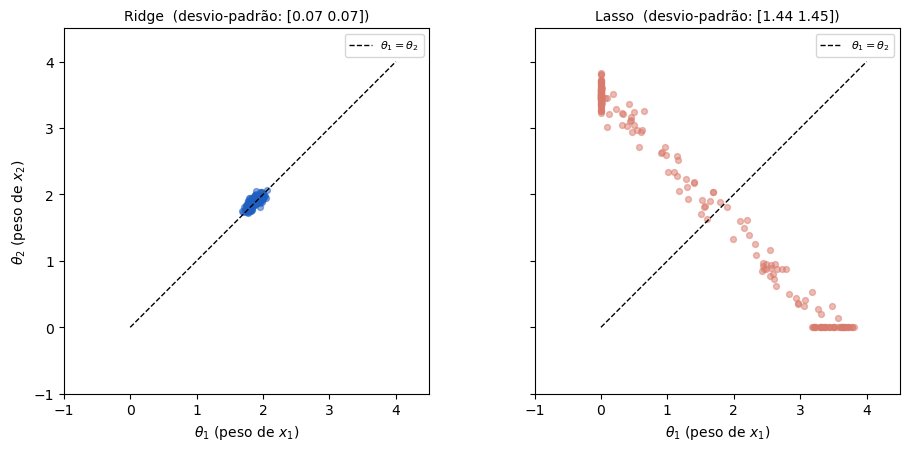

In [31]:
B = 200   # número de reamostragens bootstrap
coefs_ridge_boot, coefs_lasso_boot = [], []

for _ in range(B):
    idx = rng.integers(0, n, n)     # amostra com reposição
    Xb, yb = X_corr[idx], y_corr[idx]
    r = Ridge(alpha=5.0, fit_intercept=False).fit(Xb, yb)
    l = Lasso(alpha=0.3, fit_intercept=False, max_iter=5000).fit(Xb, yb)
    coefs_ridge_boot.append(r.coef_)
    coefs_lasso_boot.append(l.coef_)

coefs_ridge_boot = np.array(coefs_ridge_boot)
coefs_lasso_boot = np.array(coefs_lasso_boot)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6), sharex=True, sharey=True)
for ax, coefs, titulo, cor in zip(
    axes, [coefs_ridge_boot, coefs_lasso_boot], ["Ridge", "Lasso"], ["#1f5fbf", "#d97b6c"]
):
    ax.scatter(coefs[:, 0], coefs[:, 1], alpha=0.5, s=18, color=cor)
    ax.plot([0, 4], [0, 4], "k--", linewidth=1, label=r"$\theta_1=\theta_2$")
    ax.set_xlabel(r"$\theta_1$ (peso de $x_1$)")
    ax.set_title(f"{titulo}  (desvio-padrão: {coefs.std(axis=0).round(2)})", fontsize=10)
    ax.set_xlim(-1, 4.5)
    ax.set_ylim(-1, 4.5)
    ax.set_aspect("equal")
    ax.legend(fontsize=8)
axes[0].set_ylabel(r"$\theta_2$ (peso de $x_2$)")
plt.tight_layout()
plt.show()

O contraste é nítido:

- **Ridge**: os pontos ficam concentrados perto da reta $\theta_1=\theta_2 \approx 2$, pois ele **divide** o peso igualmente entre os dois atributos correlacionados, de forma estável a cada reamostragem.
- **Lasso**: os pontos ficam espalhados ao longo dos eixos, muitas vezes com um coeficiente próximo de zero e o outro carregando quase todo o peso verdadeiro (~4). A cada reamostragem, o Lasso "escolhe" um vencedor diferente entre $x_1$ e $x_2$, de forma instável.

Isso não significa que o Lasso seja um método ruim. Sua capacidade de selecionar atributos continua sendo extremamente útil, mas é importante saber que, em presença de multicolinearidade, os atributos selecionados podem não ser robustos, e a interpretação de "qual variável importa" deve ser feita com cautela.

### Elastic Net

O **Elastic Net** combina as duas penalidades em uma única função de custo:

$$
\theta^{*} = \arg\min_\theta \; \text{RSS}(\theta) + \alpha \left[ \, r \sum_{j=1}^{M} |\theta_j| \;+\; \frac{1-r}{2} \sum_{j=1}^{M} \theta_j^2 \, \right]
$$

onde $\alpha \geq 0$ controla a força total da regularização, e $r \in [0,1]$ (o parâmetro `l1_ratio` no `scikit-learn`) controla a mistura entre as duas penalidades: $r=1$ recupera o Lasso puro, $r=0$ recupera o Ridge puro.

A promessa do Elastic Net é resolver exatamente o problema que vimos na Seção 5: a componente L2 estabiliza a escolha entre atributos correlacionados (como o Ridge), enquanto a componente L1 ainda permite zerar atributos irrelevantes (como o Lasso). Vamos repetir o experimento de bootstrap, agora incluindo o Elastic Net.

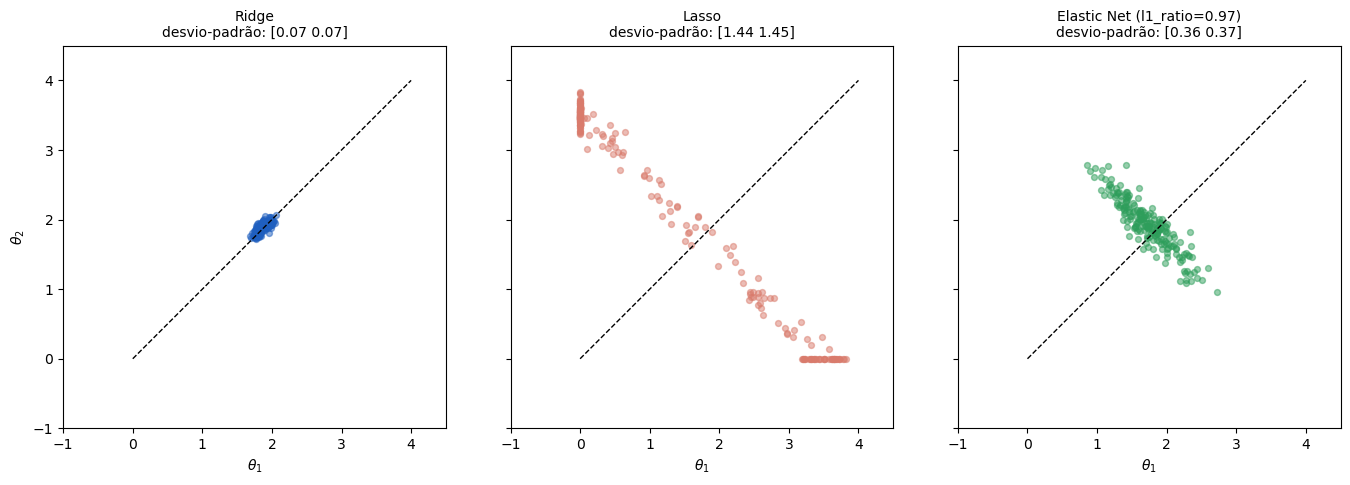

In [32]:
from sklearn.linear_model import ElasticNet

coefs_elastic_boot = []
for _ in range(B):
    idx = rng.integers(0, n, n)
    Xb, yb = X_corr[idx], y_corr[idx]
    e = ElasticNet(alpha=0.2, l1_ratio=0.97, fit_intercept=False, max_iter=5000).fit(Xb, yb)
    coefs_elastic_boot.append(e.coef_)

coefs_elastic_boot = np.array(coefs_elastic_boot)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), sharex=True, sharey=True)
for ax, coefs, titulo, cor in zip(
    axes,
    [coefs_ridge_boot, coefs_lasso_boot, coefs_elastic_boot],
    ["Ridge", "Lasso", "Elastic Net (l1_ratio=0.97)"],
    ["#1f5fbf", "#d97b6c", "#2e9e5b"],
):
    ax.scatter(coefs[:, 0], coefs[:, 1], alpha=0.5, s=18, color=cor)
    ax.plot([0, 4], [0, 4], "k--", linewidth=1)
    ax.set_xlabel(r"$\theta_1$")
    ax.set_title(f"{titulo}\ndesvio-padrão: {coefs.std(axis=0).round(2)}", fontsize=10)
    ax.set_xlim(-1, 4.5)
    ax.set_ylim(-1, 4.5)
    ax.set_aspect("equal")
axes[0].set_ylabel(r"$\theta_2$")
plt.tight_layout()
plt.show()

O Elastic Net fica visivelmente entre os dois extremos: mais estável que o Lasso puro (os pontos se aproximam mais da reta $\theta_1=\theta_2$), mas ainda mantendo alguma flexibilidade para desbalancear os pesos, diferente do Ridge. Esse equilíbrio é o motivo pelo qual o Elastic Net costuma ser a escolha padrão em problemas com muitos atributos potencialmente correlacionados (por exemplo, dados genômicos ou financeiros).

### Escolhendo o hiperparâmetro por validação cruzada

Em todos os exemplos anteriores, escolhemos $\alpha$ de maneira arbitrária para fins de ilustração. Na prática, o valor de $\alpha$ deve ser escolhido de forma sistemática, **usando apenas o conjunto de treinamento**. O conjunto de teste deve ficar reservado exclusivamente para a avaliação final, sob risco de superestimarmos a qualidade do modelo.

A técnica padrão é a **validação cruzada em $k$ partições** (*k-fold cross-validation*): o conjunto de treinamento é dividido em $k$ blocos; para cada candidato a $\alpha$, o modelo é treinado em $k-1$ blocos e avaliado no bloco restante, repetindo o processo $k$ vezes e tirando a média do desempenho. Isso fornece uma estimativa mais confiável do desempenho de generalização do que uma única divisão treino/validação.

Vamos visualizar isso como uma **curva de validação**: desempenho médio (via validação cruzada) em função de $\alpha$.

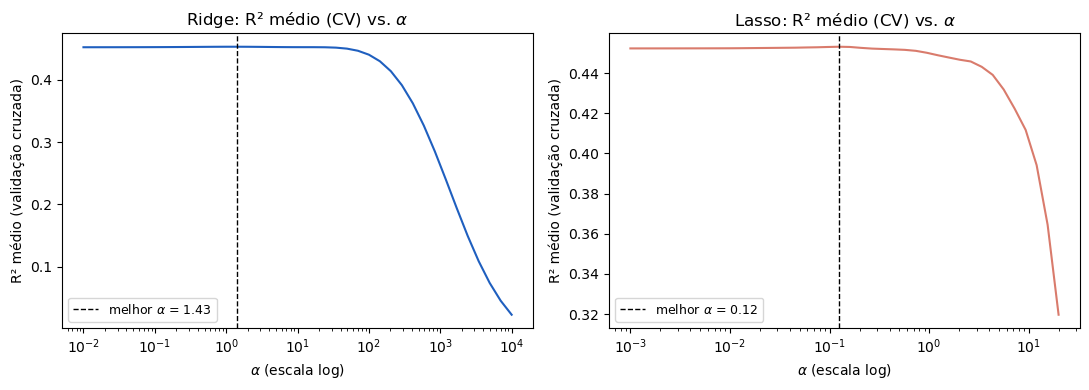

In [33]:
from sklearn.model_selection import cross_val_score

def curva_validacao(modelo_cls, alphas, **kwargs):
    scores = []
    for a in alphas:
        modelo = modelo_cls(alpha=a, **kwargs)
        s = cross_val_score(modelo, X_train_s, y_train, cv=5, scoring="r2")
        scores.append(s.mean())
    return np.array(scores)

alphas_cv_ridge = np.logspace(-2, 4, 40)
alphas_cv_lasso = np.logspace(-3, 1.3, 40)

scores_ridge = curva_validacao(Ridge, alphas_cv_ridge)
scores_lasso = curva_validacao(Lasso, alphas_cv_lasso, max_iter=10000)

melhor_alpha_ridge = alphas_cv_ridge[np.argmax(scores_ridge)]
melhor_alpha_lasso = alphas_cv_lasso[np.argmax(scores_lasso)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(alphas_cv_ridge, scores_ridge, color="#1f5fbf")
axes[0].axvline(melhor_alpha_ridge, color="black", linestyle="--", linewidth=1,
                 label=fr"melhor $\alpha$ = {melhor_alpha_ridge:.2f}")
axes[0].set_xscale("log")
axes[0].set_title("Ridge: R² médio (CV) vs. $\\alpha$")

axes[1].plot(alphas_cv_lasso, scores_lasso, color="#d97b6c")
axes[1].axvline(melhor_alpha_lasso, color="black", linestyle="--", linewidth=1,
                 label=fr"melhor $\alpha$ = {melhor_alpha_lasso:.2f}")
axes[1].set_xscale("log")
axes[1].set_title("Lasso: R² médio (CV) vs. $\\alpha$")

for ax in axes:
    ax.set_xlabel(r"$\alpha$ (escala log)")
    ax.set_ylabel("R² médio (validação cruzada)")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

O padrão típico é: o desempenho de validação fica **estável** (um platô) para valores pequenos de $\alpha$. A regularização ainda é fraca, mas com $n=442$ pacientes e apenas 10 atributos há dados suficientes para que o overfitting não seja severo mesmo sem regularização. Depois **cai** quando $\alpha$ fica grande demais, porque a penalidade passa a empurrar até os coeficientes realmente importantes para perto de zero (underfitting). O melhor $\alpha$ fica na borda desse platô, marcado pela linha tracejada em cada gráfico.

Em problemas com **muito mais atributos do que observações** (ou com atributos muito ruidosos), é comum que esse platô inicial dê lugar a uma queda **também** para $\alpha$ pequeno, formando o clássico "U" invertido. Como o overfitting é discreto aqui, essa subida à esquerda não fica visível nesta base de dados específica, mas o princípio (regularização fraca demais também pode prejudicar a generalização) continua valendo.

Fazer essa busca manualmente célula por célula seria tedioso, por isso o `scikit-learn` oferece versões prontas (`RidgeCV`, `LassoCV`, `ElasticNetCV`) que automatizam exatamente esse processo.

In [34]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score

ridge_cv = RidgeCV(alphas=alphas_cv_ridge, cv=5).fit(X_train_s, y_train)
lasso_cv = LassoCV(alphas=alphas_cv_lasso, cv=5, max_iter=10000, random_state=42).fit(X_train_s, y_train)
elastic_cv = ElasticNetCV(
    alphas=alphas_cv_lasso, l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
    cv=5, max_iter=10000, random_state=42,
).fit(X_train_s, y_train)

for nome, modelo in [("Ridge", ridge_cv), ("Lasso", lasso_cv), ("Elastic Net", elastic_cv)]:
    y_pred = modelo.predict(X_test_s)
    rmse_teste = np.sqrt(mean_squared_error(y_test, y_pred))
    r2_teste = r2_score(y_test, y_pred)
    extra = f", l1_ratio={modelo.l1_ratio_:.2f}" if hasattr(modelo, "l1_ratio_") else ""
    print(f"{nome:12s} | alpha={modelo.alpha_:8.3f}{extra:16s} | RMSE(teste)={rmse_teste:6.2f} | R2(teste)={r2_teste:.3f}")

Ridge        | alpha=   1.425                 | RMSE(teste)= 53.10 | R2(teste)=0.478
Lasso        | alpha=   0.097                 | RMSE(teste)= 53.08 | R2(teste)=0.478
Elastic Net  | alpha=   0.004, l1_ratio=0.10  | RMSE(teste)= 53.10 | R2(teste)=0.478


### Comparação

Para fechar, comparamos os quatro modelos, regressão linear simples, Ridge, Lasso e Elastic Net (os três últimos com $\alpha$ escolhido por validação cruzada) no **mesmo** conjunto de teste da base Diabetes, incluindo o **número de atributos com coeficiente não nulo** como uma medida direta de esparsidade/interpretabilidade.

In [35]:
import pandas as pd
from sklearn.linear_model import LinearRegression

lm = LinearRegression().fit(X_train_s, y_train)

modelos = {
    "Regressão linear": lm,
    "Ridge (RidgeCV)": ridge_cv,
    "Lasso (LassoCV)": lasso_cv,
    "Elastic Net (ElasticNetCV)": elastic_cv,
}

linhas = []
for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_test_s)
    coef = modelo.coef_
    linhas.append({
        "Modelo": nome,
        "RMSE (teste)": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2 (teste)": r2_score(y_test, y_pred),
        "Atributos usados": int(np.sum(np.abs(coef) > 1e-6)),
        "|coef| médio": np.mean(np.abs(coef)),
    })

resultados = pd.DataFrame(linhas)
resultados

,Modelo,RMSE (teste),R2 (teste),Atributos usados,|coef| médio
0,Regressão linear,53.120156,0.477290,10,17.940790
1,Ridge (RidgeCV),53.101907,0.477649,10,14.365074
2,Lasso (LassoCV),53.077857,0.478122,9,14.437369
3,Elastic Net (ElasticNetCV),53.103452,0.477618,10,15.172476


Alguns pontos costumam se repetir em bases de dados reais (embora os números exatos variem conforme os dados):

- A regressão linear sem regularização tende a ter o **maior** RMSE de teste (ou muito próximo do Ridge) quando há multicolinearidade, pois seus coeficientes têm alta variância.
- O **Ridge** costuma ter desempenho preditivo muito bom, mas usa **todos** os atributos.
- O **Lasso** reduz o número de atributos usados, às vezes com uma pequena perda de desempenho preditivo em troca de maior interpretabilidade.
- O **Elastic Net** costuma ficar em um meio-termo, competitivo em desempenho e ainda oferecendo alguma esparsidade.

Não existe um "vencedor" universal. A escolha depende do que importa mais no seu problema: desempenho puro, interpretabilidade, ou robustez a atributos correlacionados.

## Resumo

- A complexidade de um modelo precisa ser balanceada com a quantidade de dados disponíveis: modelos simples demais sofrem de **underfitting** (viés alto); modelos complexos demais, de **overfitting** (variância alta).
- A **regularização** controla essa complexidade penalizando coeficientes grandes na função de custo, sem precisar reduzir manualmente o número de atributos.
- **Ridge (L2)**: penalidade $\sum \theta_j^2$; encolhe os coeficientes suavemente; nunca zera exatamente; tem solução fechada; lida bem com atributos correlacionados (divide o peso entre eles de forma estável).
- **Lasso (L1)**: penalidade $\sum |\theta_j|$; pode zerar coeficientes exatamente, funcionando como seleção automática de atributos; pode ser **instável** quando há atributos fortemente correlacionados.
- **Elastic Net**: combina as duas penalidades, buscando o equilíbrio entre a estabilidade do Ridge e a esparsidade do Lasso.
- Em todos os casos: (1) **padronize** os atributos antes de regularizar, e (2) escolha $\alpha$ (e `l1_ratio`, no caso do Elastic Net) por **validação cruzada no conjunto de treinamento**, nunca observando o conjunto de teste.

## Exercícios de fixação

1. Escolha outra base para realizar a regressão (por exemplo a base de concreto) e Repita a análise.

2. Na primeira parte do notebook, onde ajustamos um polinômio aos dados da função seno, ajuste um polinômio de grau $M=15$ usando Ridge e Lasso (em vez de regressão linear comum) com um valor pequeno de $\alpha$, escolhido por validação cruzada. Compare visualmente o resultado com o ajuste sem regularização.